In [1]:
import pandas as pd
import numpy as np

# 数据列表，每行对应表格的一行
data_wbtq = [
    ["Qwen2.5-7B-Instruct", "minimal+reranker", 181, 266, 180, 274, 377, 560.74, 1146, 423, 656, 0.7264],
    ["Qwen2.5-7B-Instruct", "minimal+rewriter+reranker", 189, 254, 179, 247, 393, 893.31, 1186, 412, 569, 0.7170],
    ["Qwen2.5-7B-Instruct", "minimal+reranker+summarizer", 37, 152, 37, 155, 199, 216.34, 336, 289, 457, 0.6795],
    ["Qwen2.5-14B-Instruct", "minimal+reranker", 178, 319, 173, 336, 377, 260.2, 630, 424, 635, 0.7260],
    ["Qwen2.5-14B-Instruct", "minimal+rewriter+reranker", 157, 315, 154, 337, 378, 341.54, 618, 413, 651, 0.7191],
    ["Qwen2.5-14B-Instruct", "minimal+reranker+summarizer", 18, 144, 18, 144, 202, 141.13, 331, 342, 553, 0.7077],
    ["Qwen2.5-32B-Instruct", "minimal+reranker", 198, 340, 194, 352, 356, 178.61, 457, 406, 548, 0.7215],
    ["Qwen2.5-32B-Instruct", "minimal+rewriter+reranker", 168, 284, 167, 294, 324, 232.76, 403, 351, 479, 0.7108],
    ["Qwen2.5-32B-Instruct", "minimal+reranker+summarizer", 20, 141, 20, 143, 181, 118.83, 240, 294, 459, 0.6872],
    # Qwen3 系列空白行，使用 NaN
    ["Qwen3-8B", "minimal+reranker", np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan],
    ["Qwen3-8B", "minimal+rewriter+reranker", np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan],
    ["Qwen3-8B", "minimal+reranker+summarizer", np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan],
    ["Qwen3-14B", "minimal+reranker", np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan],
    ["Qwen3-14B", "minimal+rewriter+reranker", np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan],
    ["Qwen3-14B", "minimal+reranker+summarizer", np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan],
    ["Qwen3-32B", "minimal+reranker", np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan],
    ["Qwen3-32B", "minimal+rewriter+reranker", np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan],
    ["Qwen3-32B", "minimal+reranker+summarizer", np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan],
]

# 创建 DataFrame
columns = [
    "LLM", "RAG",
    "rougeL_prompt08", "rougeL_prompt05", "rougeL_chunk08", "rougeL_chunk05",
    "context_prompt", "avg_words_length", "context_chunk", "embed_prompt", "embed_chunk", "avg_mean_sim"
]

df_wbtq = pd.DataFrame(data_wbtq, columns=columns)


import pandas as pd
import numpy as np

# 假设 df 已经存在
# 示例拆分
df_wbtq["reranker"] = df_wbtq["RAG"].str.contains("reranker", case=False, na=False)
df_wbtq["rewriter"] = df_wbtq["RAG"].str.contains("rewriter", case=False, na=False)
df_wbtq["summarizer"] = df_wbtq["RAG"].str.contains("summarizer", case=False, na=False)

# 可选：把原 RAG 列删除
# df_wbtq = df_wbtq.drop(columns=["RAG"])

# 查看结果
df_wbtq.head()

,LLM,RAG,rougeL_prompt08,rougeL_prompt05,rougeL_chunk08,rougeL_chunk05,context_prompt,avg_words_length,context_chunk,embed_prompt,embed_chunk,avg_mean_sim,reranker,rewriter,summarizer
0,Qwen2.5-7B-Instruct,minimal+reranker,181.0,266.0,180.0,274.0,377.0,560.74,1146.0,423.0,656.0,0.7264,True,False,False
1,Qwen2.5-7B-Instruct,minimal+rewriter+reranker,189.0,254.0,179.0,247.0,393.0,893.31,1186.0,412.0,569.0,0.7170,True,True,False
2,Qwen2.5-7B-Instruct,minimal+reranker+summarizer,37.0,152.0,37.0,155.0,199.0,216.34,336.0,289.0,457.0,0.6795,True,False,True
3,Qwen2.5-14B-Instruct,minimal+reranker,178.0,319.0,173.0,336.0,377.0,260.20,630.0,424.0,635.0,0.7260,True,False,False
4,Qwen2.5-14B-Instruct,minimal+rewriter+reranker,157.0,315.0,154.0,337.0,378.0,341.54,618.0,413.0,651.0,0.7191,True,True,False


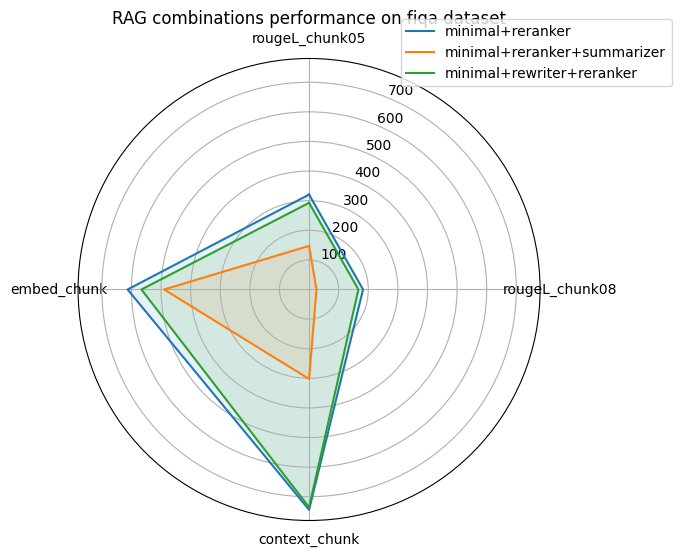

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 选择你想展示的指标
metrics = ["rougeL_chunk05", "rougeL_chunk08", "context_chunk", "embed_chunk"]

# 按 RAG 分组取均值（可以按 LLM 进一步筛选，如果只看某个模型）
df_plot = df_wbtq.groupby("RAG")[metrics].mean()

# 准备雷达图
labels = metrics
num_vars = len(labels)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # 闭合多边形

fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))

# 绘制每个 RAG
for rag in df_plot.index:
    values = df_plot.loc[rag].tolist()
    values += values[:1]  # 闭合
    ax.plot(angles, values, label=rag)
    ax.fill(angles, values, alpha=0.1)

# 设置雷达图
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels)
ax.set_title("RAG combinations performance on fiqa dataset")
ax.grid(True)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

plt.show()

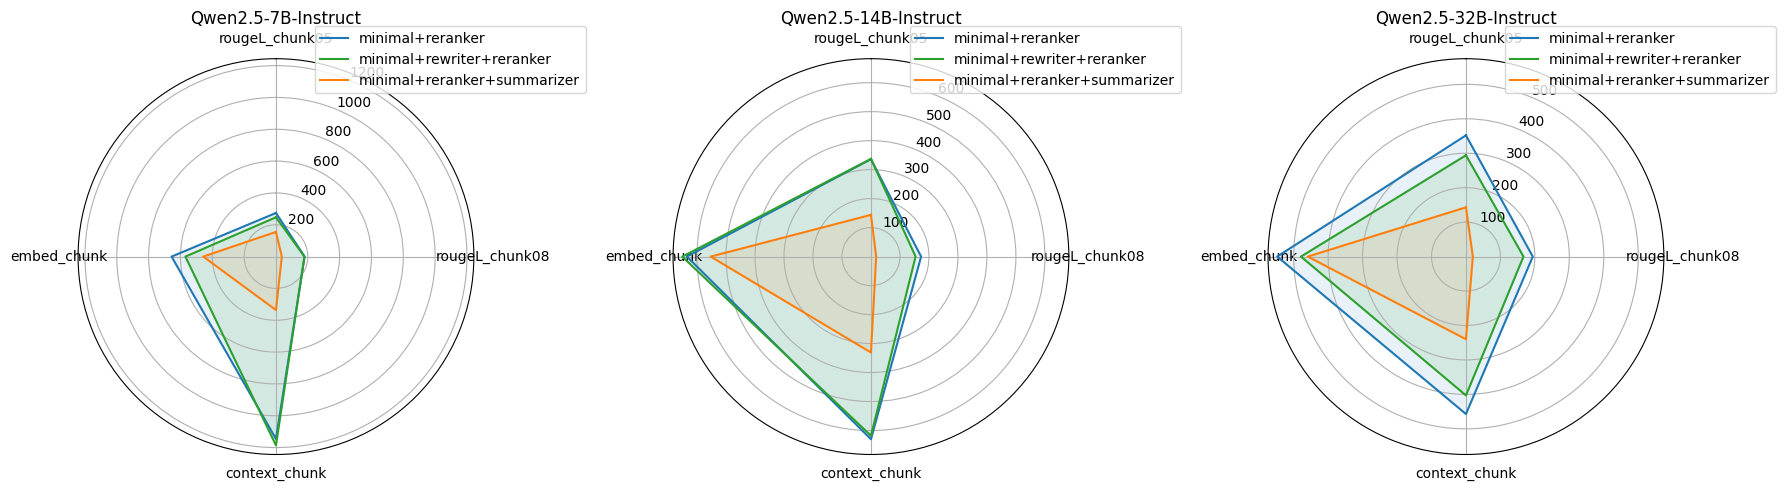

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# 你想要的 RAG 顺序
desired_order = ["minimal+reranker", "minimal+rewriter+reranker", "minimal+reranker+summarizer"]

# 指标
metrics = ["rougeL_chunk05", "rougeL_chunk08", "context_chunk", "embed_chunk"]

# 只保留有数据的 LLM
llms_with_data = []
for llm in df_wbtq["LLM"].unique():
    df_l = df_wbtq[df_wbtq["LLM"] == llm]
    if df_l[metrics].notna().any().any():
        llms_with_data.append(llm)

n_llm = len(llms_with_data)
fig, axes = plt.subplots(1, n_llm, figsize=(6*n_llm, 6), subplot_kw=dict(polar=True))
if n_llm == 1:
    axes = [axes]

for ax, llm in zip(axes, llms_with_data):
    df_l = df_wbtq[df_wbtq["LLM"] == llm]
    df_plot = df_l.groupby("RAG")[metrics].mean()
    
    # 跳过整行全 NaN 的 RAG
    df_plot = df_plot.dropna(how="all")
    if df_plot.empty:
        ax.set_title(f"{llm} (no data)")
        continue
    
    # 归一化
    # scaler = MinMaxScaler()
    # df_scaled = pd.DataFrame(scaler.fit_transform(df_plot), index=df_plot.index, columns=metrics)
    df_scaled = df_plot.copy()
    
    # 雷达图角度
    angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
    angles += angles[:1]
    
    # 绘制每个 RAG
    for rag in df_scaled.index:
        values = df_scaled.loc[rag].tolist()
        values += values[:1]  # 闭合
        # ax.plot(angles, values, label=rag, marker='o')  # 加 marker
        ax.plot(angles, values, label=rag)  # 加 marker
        ax.fill(angles, values, alpha=0.1)
    
    # 设置雷达图样式
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.degrees(angles[:-1]), metrics)
    ax.set_title(f"{llm}")
    ax.grid(True)
    
    # legend 按指定顺序
    handles, labels = ax.get_legend_handles_labels()
    order = [labels.index(rag) for rag in desired_order if rag in labels]
    handles = [handles[i] for i in order]
    labels = [labels[i] for i in order]
    ax.legend(handles, labels, loc="upper right", bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.show()

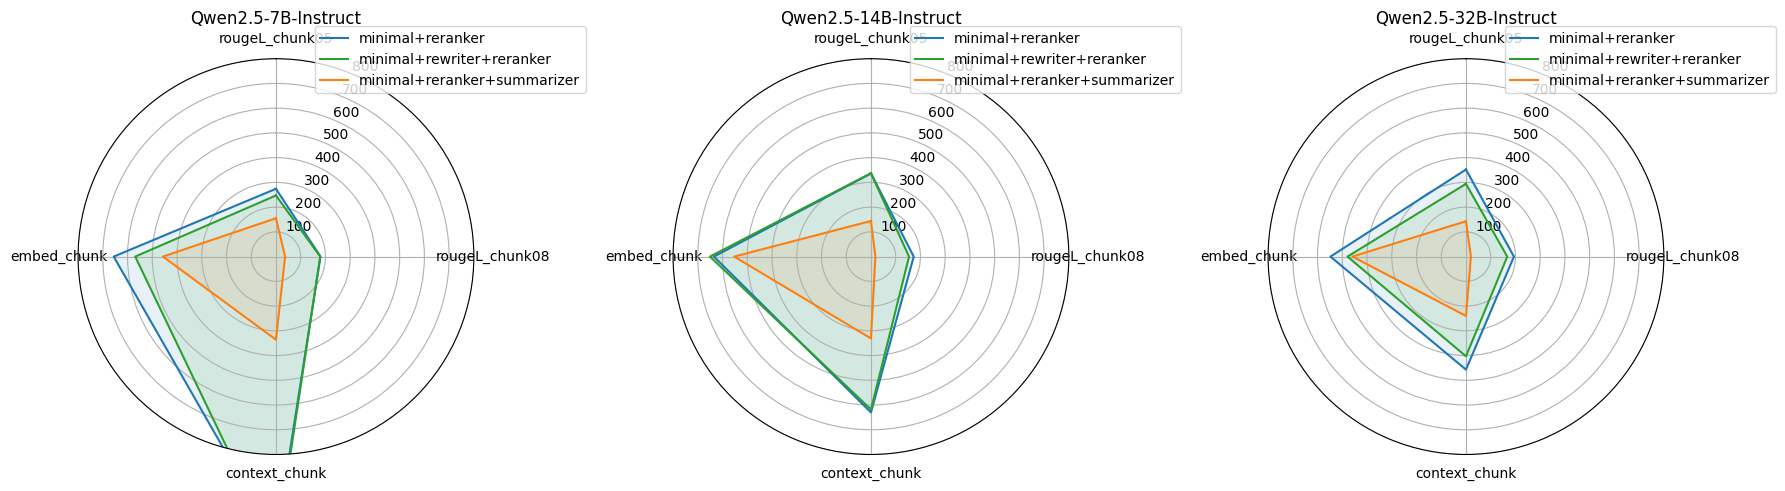

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 你想要的 RAG 顺序
desired_order = ["minimal+reranker", "minimal+rewriter+reranker", "minimal+reranker+summarizer"]
# metrics = ["rougeL_chunk05", "rougeL_chunk08", "context_chunk", "embed_chunk", "avg_mean_sim"]
metrics = ["rougeL_chunk05", "rougeL_chunk08", "context_chunk", "embed_chunk"]

# 自定义最大值
max_val = 800  # <-- 改成你需要的最大值

sim_scale = 800  # 将相似度指标放大以匹配其他指标的范围

llms_with_data = [llm for llm in df_wbtq["LLM"].unique()
                  if df_wbtq[df_wbtq["LLM"] == llm][metrics].notna().any().any()]

n_llm = len(llms_with_data)
fig, axes = plt.subplots(1, n_llm, figsize=(6*n_llm, 6), subplot_kw=dict(polar=True))
if n_llm == 1:
    axes = [axes]

for ax, llm in zip(axes, llms_with_data):
    df_l = df_wbtq[df_wbtq["LLM"] == llm]
    df_plot = df_l.groupby("RAG")[metrics].mean().dropna(how="all")
    if df_plot.empty:
        ax.set_title(f"{llm} (no data)")
        continue

    # ✅ 单独对 avg_mean_sim 放大
    if "avg_mean_sim" in df_plot.columns:
        df_plot["avg_mean_sim"] = df_plot["avg_mean_sim"] * sim_scale

    angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
    angles += angles[:1]

    for rag in df_plot.index:
        values = df_plot.loc[rag].tolist()
        values += values[:1]
        ax.plot(angles, values, label=rag)
        ax.fill(angles, values, alpha=0.1)

    # 仅设置 r 轴范围上限为 max_val（数据本身不变）
    ax.set_ylim(0, max_val)

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.degrees(angles[:-1]), metrics)
    ax.set_title(f"{llm}")
    ax.grid(True)

    handles, labels = ax.get_legend_handles_labels()
    order = [labels.index(rag) for rag in desired_order if rag in labels]
    handles = [handles[i] for i in order]
    labels = [labels[i] for i in order]
    ax.legend(handles, labels, loc="upper right", bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.show()